# 04 · Does the *wording* predict the price?

*Rent Reality Check — London. Created by **Kevin Steepan**.*

---

## What this notebook is (in one minute)

Notebook 03 built a model from a listing's **facts** — size, type, location,
amenities. This notebook asks a different question:

> **Does *how a host writes the description* tell you anything about price that the
> facts don't already?**

Two hosts with an identical flat can write:

- *"STUNNING luxurious designer apartment in the heart of vibrant Shoreditch!!!"*
- *"1-bed flat, 4 min walk to Old Street station, wifi, quiet street."*

Intuition says the first host is *signalling* "premium" and probably charging more.
But maybe that's just because they genuinely have a nicer flat — which the facts
*already_ capture. The only way to know is a **controlled comparison**: give a model
the facts, then give it the facts *plus* text, and see if it gets better.

### The plan

1. Look at the descriptions — length, examples, cleaning.
2. Build a dozen **"style" features** (how long, how SHOUTY, how many marketing
   words) and see how they relate to price.
3. **Bag-of-words**: let the data tell us which *words* go with pricier listings.
4. The experiment: **facts** vs **facts + style** vs **facts + word-topics**, all
   under the same honest spatial cross-validation from notebook 03.
5. What it means, and where this approach falls short.

> 📚 The "add a feature group, re-measure under the same CV" method is the same
> ablation discipline as notebook 02. The text techniques here (TF-IDF, latent
> components) are the classic pre-deep-learning NLP toolkit — covered in the
> scikit-learn "Working with text data" tutorial and in Jurafsky & Martin's
> *Speech and Language Processing* (ch. on vector semantics).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from londonrent.features import build_model_frame
from londonrent import model as M
from londonrent.text import style_features, STYLE_FEATURES, clean_description

# keep_text=True carries the raw `description` through. with_reviews=False because
# the description is a COLD-START feature - you write it when you create the
# listing, before any reviews exist - so it belongs with the cold-start model,
# not the review-aware one.
frame, groups = build_model_frame(with_reviews=False, keep_text=True)
y = frame["log_price"].to_numpy()
print(f"{len(frame):,} listings")
print("has a description:", (frame['description'].fillna('').str.len() > 0).mean().round(3))

60,648 listings
has a description: 0.988


## 1 · Look at the text

SHORTEST non-empty:
  .

MOST '!' :
  A cozy two bedroom flat able to accommodate 4 people comfortably! There is one bathroom/shower! One small kitchen! One good size living room which you can use to relax or to do some homework/job! All the furniture are in good conditions, most of them in white (my favourite colour)! Heated flat if yo


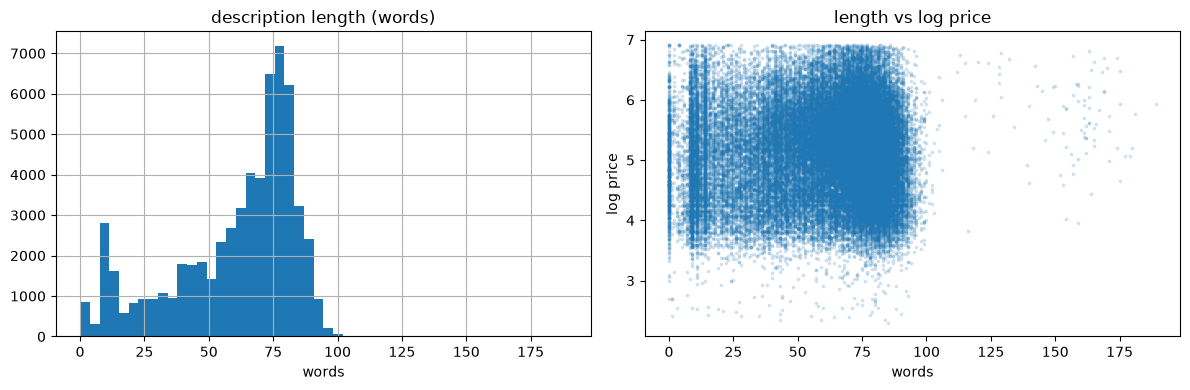

In [2]:
desc = clean_description(frame["description"])   # strip HTML, collapse whitespace
wc = desc.str.count(r"\S+")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
wc.hist(bins=50, ax=ax[0]); ax[0].set_title("description length (words)"); ax[0].set_xlabel("words")
ax[1].scatter(wc, y, s=3, alpha=.15); ax[1].set_title("length vs log price")
ax[1].set_xlabel("words"); ax[1].set_ylabel("log price")
plt.tight_layout()

# the shortest and one very promotional example, to get a feel for the range
print("SHORTEST non-empty:\n ", desc[desc.str.len() > 0].sort_values(key=lambda s: s.str.len()).iloc[0][:300])
print("\nMOST '!' :\n ", desc.iloc[desc.str.count('!').argmax()][:300])

**What we see.** Most descriptions are 40–90 words (Inside Airbnb truncates them,
so there's a hard ceiling near ~190). Length has a *weak* positive relationship with
price — pricier listings tend to have slightly more to say — but it's noisy.

### Deeper: a preview of the whole notebook's problem

That length–price link is real but it's almost certainly **not because longer text
causes higher prices**. Bigger, fancier flats have more features to list *and* cost
more. Every text signal in this notebook has this issue: text correlates with the
facts, and the facts drive price. The experiment in section 4 is designed to strip
that out by asking whether text helps *after the model already has the facts*.

## 2 · Hand-crafted "style" features

Instead of the words themselves, describe *how the description is written*:

In [3]:
style = style_features(frame["description"])
style.describe(percentiles=[.5, .9]).T.round(2)

,count,mean,std,min,50%,90%,max
desc_word_count,60648.0,60.72,24.04,0.0,69.00,84.00,189.0
desc_avg_word_len,60648.0,6.04,0.85,0.0,6.10,6.75,15.5
desc_exclamations,60648.0,0.22,0.58,0.0,0.00,1.00,13.0
desc_question_marks,60648.0,0.01,0.13,0.0,0.00,0.00,7.0
desc_uppercase_ratio,60648.0,0.04,0.05,0.0,0.04,0.07,1.0
desc_digit_ratio,60648.0,0.01,0.01,0.0,0.00,0.02,1.0
desc_has_emoji,60648.0,0.05,0.23,0.0,0.00,0.00,1.0
desc_luxury_hits,60648.0,0.53,0.82,0.0,0.00,2.00,7.0
desc_practical_hits,60648.0,3.36,2.49,0.0,3.00,7.00,20.0
desc_tone,60648.0,-2.83,2.65,-20.0,-3.00,0.00,6.0


In [4]:
# How does each style feature relate to price? (linear correlation, same as
# notebooks 01-02.) Positive = this style goes with pricier listings.
corr = pd.concat([style, pd.Series(y, name="log_price", index=style.index)], axis=1)
corr = corr.corr(numeric_only=True)["log_price"].drop("log_price").sort_values()
corr.to_frame("corr with log_price").round(3)

,corr with log_price
desc_practical_hits,-0.106
desc_digit_ratio,-0.003
desc_exclamations,0.007
desc_uppercase_ratio,0.009
desc_question_marks,0.010
desc_has_emoji,0.046
desc_word_count,0.061
desc_avg_word_len,0.136
desc_tone,0.174
desc_luxury_hits,0.241


**What we see.** The correlations are all small, but they line up with intuition:

| feature | corr with log price |
|---|---|
| `desc_luxury_hits` | **+0.24** |
| `desc_tone` (luxury − practical words) | +0.17 |
| `desc_avg_word_len` | +0.14 |
| `desc_word_count` | +0.06 |
| `desc_practical_hits` | **−0.11** |
| `desc_exclamations`, `desc_uppercase_ratio`, `desc_digit_ratio` | ≈ 0 |

So descriptions that reach for marketing adjectives ("stunning", "luxurious") do
sit with pricier listings; descriptions full of practical logistics ("station",
"wifi", "shared") sit with cheaper ones. **SHOUTY-ness on its own is not a premium
signal** — `desc_exclamations` and `desc_uppercase_ratio` are flat.

### Deeper: why "small and messy" is the expected result

These features are crude proxies. `desc_luxury_hits` counts the literal word
"luxury" — it can't tell genuine boutique copy from a bog-standard flat whose host
likes the word. And because the *facts* explain most of the price, anything these
features add has to be *residual* signal — whatever's left after size, location and
type. A correlation of 0.24 is real but it's `0.24² ≈ 6%` of the variation, from a
feature that overlaps heavily with "big central flat". Section 4 measures the bit
that actually matters: the *incremental* value once the model already has the facts.

## 3 · Bag-of-words: which *words* go with price?

Now the words themselves. **TF-IDF** turns each description into a long vector of
numbers, one per word in the vocabulary.

### Deeper: what TF-IDF actually computes

For a word *w* in description *d*:

- **TF** (term frequency) — how often *w* appears in *d*. We use `sublinear_tf`, i.e.
  `1 + log(count)`, so a word appearing 10 times isn't treated as 10× as important
  as appearing once.
- **IDF** (inverse document frequency) — `log(N / (docs containing w))`. Words in
  *every* description ("the", "flat") get a tiny weight; rare, distinctive words get
  a big one.
- The feature is **TF × IDF**, then the vector is length-normalised.

We also include **bigrams** (`ngram_range=(1,2)`) so "5 minute" and "private
garden" are single features, and drop words in fewer than 20 or more than 40% of
descriptions (noise floor and ceiling).

To read off "which words track price", we fit a plain **ridge regression** from the
TF-IDF vectors to `log_price` and look at the largest positive and negative
coefficients.

> 📚 TF-IDF and text classification pipelines: the scikit-learn "Working With Text
> Data" tutorial. The linear-model-on-TF-IDF-then-inspect-coefficients trick for
> interpretability is a staple of applied NLP write-ups.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

vec = TfidfVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1, 2), min_df=20, max_df=0.4, sublinear_tf=True,
    max_features=30000,
)
Xtxt = vec.fit_transform(desc)
print("TF-IDF matrix:", Xtxt.shape, f"({Xtxt.nnz / (Xtxt.shape[0]*Xtxt.shape[1]):.3%} non-zero)")

# fit on ALL rows just to inspect coefficients (this is interpretation, not
# evaluation - the honest scoring happens in section 4 with proper folds)
ridge_txt = Ridge(alpha=1.0).fit(Xtxt, y)
coef = pd.Series(ridge_txt.coef_, index=vec.get_feature_names_out())
print("\n--- words/phrases most associated with HIGHER price ---")
print(coef.sort_values(ascending=False).head(20).round(3).to_string())
print("\n--- most associated with LOWER price ---")
print(coef.sort_values().head(20).round(3).to_string())

TF-IDF matrix: (60648, 18724) (0.298% non-zero)



--- words/phrases most associated with HIGHER price ---
bedrooms               2.317
families               1.834
bedroom bathroom       1.512
accommodation great    1.430
family                 1.327
townhouse              1.288
bathrooms              1.225
living room            1.219
apartment              1.200
mews                   1.141
group                  1.122
beds                   1.110
lots room              1.077
ideal groups           1.073
bedroom house          1.069
cooling                1.043
fitness center         1.040
double reception       1.033
royalty                1.013
mayfair                1.011

--- most associated with LOWER price ---
room                -2.746
shared              -1.409
bedroom available   -1.233
located north       -1.049
sharing             -1.048
studio apartment    -1.024
private bedroom     -1.022
redbridge           -1.004
bedroom bedroom     -0.997
flatmates           -0.991
croydon             -0.988
share               -0.9

**What we see.** The lists are almost entirely about **size and room-type**, with a
little location:

- **Higher price:** `bedrooms`, `families`, `bedroom bathroom`, `townhouse`, `beds`,
  `ideal groups`, `mews`, `bedroom house`, `fitness center`, `mayfair`, `royalty` —
  i.e. "this is a whole multi-bedroom home for a group", plus a couple of genuine
  premium cues.
- **Lower price:** `room`, `shared`, `sharing`, `bedroom available`, `studio
  apartment`, `flatmates`, `single`, `female`, plus cheap-borough names
  (`redbridge`, `croydon`) — i.e. "this is a single room in a shared flat".

### Deeper: this is correlation, dressed up

The ridge coefficient on "mayfair" being large and positive does **not** mean
writing "Mayfair" adds value. It means listings whose descriptions say "Mayfair"
*are in Mayfair* — expensive for reasons the facts already know. Same for "bedrooms"
(the model already has `bedrooms` as a number). The word list is a great sanity
check and genuinely readable, but it is **not** a set of levers a host can pull.
Keep that separation clear when presenting it.

## 4 · The experiment: does text help *on top of the facts*?

Same honest setup as notebook 03: `HistGradientBoostingRegressor`, 5-fold
**spatial** cross-validation, only the feature list changes.

- **A · facts only** — the cold-start feature set from notebook 03.
- **B · facts + style** — plus the 10 hand-crafted style features.
- **C · facts + word-topics** — plus 50 components from `TruncatedSVD` of the
  TF-IDF matrix.

### Deeper: why `TruncatedSVD`, and not "just add the 30,000 TF-IDF columns"

Dumping 30k mostly-zero columns into a tree model is slow and invites overfitting
on rare words. **`TruncatedSVD`** (a.k.a. **LSA**, latent semantic analysis)
factorises the big sparse matrix into a handful of dense components — each a
weighted blend of co-occurring words, a rough "topic". 50 numbers per listing
instead of 30,000, and it works directly on sparse input. We fit the SVD **inside
the loop is overkill** for a first pass, so we fit it once on all rows; that leaks a
little (the components are informed by the test rows' word statistics, though not
their prices) — noted in the limitations and worth tightening in a v2.

> 📚 `TruncatedSVD` / LSA: scikit-learn "Decomposing signals in components" user
> guide; Deerwester et al. (1990) for the original LSA idea.

In [6]:
from sklearn.decomposition import TruncatedSVD

enc = M.fit_encoder(frame, groups["categorical"])
X_facts = M.build_design_matrix(frame, groups, enc)
folds = M.spatial_block_folds(frame["latitude"].to_numpy(),
                              frame["longitude"].to_numpy(), n_splits=5, seed=0)

# 50 dense "topic" components from the TF-IDF matrix
svd = TruncatedSVD(n_components=50, random_state=0)
topics = pd.DataFrame(svd.fit_transform(Xtxt),
                      columns=[f"topic_{i:02d}" for i in range(50)],
                      index=frame.index)
print(f"SVD keeps {svd.explained_variance_ratio_.sum():.1%} of the TF-IDF variance in 50 numbers")

X_style  = pd.concat([X_facts, style[STYLE_FEATURES]], axis=1)
X_topics = pd.concat([X_facts, topics], axis=1)

def oof(Xmat):
    pred = np.full(len(y), np.nan)
    for tr, te in folds:
        m = M.make_model(); m.fit(Xmat.iloc[tr], y[tr]); pred[te] = m.predict(Xmat.iloc[te])
    return pred

rows = {
    "A · facts only":        M.evaluate(y, oof(X_facts)),
    "B · facts + style":     M.evaluate(y, oof(X_style)),
    "C · facts + word-topics": M.evaluate(y, oof(X_topics)),
}
pd.DataFrame(rows).T.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

SVD keeps 13.3% of the TF-IDF variance in 50 numbers


,MAE_gbp,MdAPE,within_15pct,R2_log
A · facts only,62.2280,0.2233,0.3516,0.7128
B · facts + style,61.2667,0.2193,0.3556,0.7186
C · facts + word-topics,60.4854,0.2166,0.3598,0.7237


### Also useful: how well does text do *alone*?

A quick text-only score (TF-IDF → ridge, same folds) as a reference point — it
tells us how much price information is in the words *before* the facts are
subtracted out.

In [7]:
from sklearn.linear_model import Ridge

pred_txt = np.full(len(y), np.nan)
for tr, te in folds:
    v = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2),
                        min_df=20, max_df=0.4, sublinear_tf=True, max_features=30000)
    Xtr = v.fit_transform(desc.iloc[tr])          # fit the vectoriser on TRAIN ONLY (no leak)
    r = Ridge(alpha=1.0).fit(Xtr, y[tr])
    pred_txt[te] = r.predict(v.transform(desc.iloc[te]))

pd.Series(M.evaluate(y, pred_txt)).round(4)

MAE_gbp          88.2638
RMSE_gbp        137.9453
MdAPE             0.3260
within_15pct      0.2425
MAE_log           0.4207
R2_log            0.4491
dtype: float64

**What we see.**

| model | £-MAE | median % err | within ±15% | R²(log) |
|---|---|---|---|---|
| text only (TF-IDF → ridge) | 88.3 | 32.6% | 24% | 0.449 |
| **A · facts only** | **62.2** | **22.3%** | **35.2%** | **0.713** |
| B · facts + style | 61.3 | 21.9% | 35.6% | 0.719 |
| C · facts + word-topics | 60.5 | 21.7% | 36.0% | 0.724 |

Read it like this:

- **Text alone** gets R² ≈ 0.45 / £88 MAE — roughly the notebook-01 baseline. The
  words *do* carry real price information, but it's mostly the description leaking
  the facts (room vs whole flat, borough names, "townhouse" vs "studio").
- The number that answers this notebook's question is **B and C minus A**:
  style features add **£0.9 / +0.006 R²**, word-topics add **£1.7 / +0.011 R²**.
  Small, consistent, and in the right direction — but small.

### Deeper: interpreting a small gain

A ~£1.7/night, ~0.01-R² improvement from 50 text components is a **real but minor**
effect, and it's worth stating exactly what it is and isn't:

- It's most likely the text acting as a **proxy for unmeasured quality** — a host
  with a tastefully refitted flat, a good view, or a design-led interior (none of
  which are structured fields) tends to write richer copy, and the model picks up
  on that residue.
- It is **not** evidence that better copywriting raises the price you can charge —
  the text and the price were both set by the same host, so we can only say they
  move together.
- **Practical takeaway:** a pricing tool for this dataset does **not** need NLP.
  The structured features are very close to a sufficient statistic for price; the
  description adds a rounding error. That's a useful negative result — it keeps the
  deployed model simpler and cheaper to run (the app ships the facts-only model).

## 5 · Honest limitations

- **The text isn't independent of the target.** The same host who wrote the
  description also set the price. We're not measuring "does good copy raise price",
  we're measuring "do the two move together".
- **Bag-of-words has no understanding.** TF-IDF can't tell "*not* central" from
  "central", can't do sarcasm, and treats "5 minute walk to the tube" as three
  unrelated tokens plus two bigrams. Negation and word order are lost.
- **The SVD is fit on all rows.** Its components see the test rows' word
  statistics (not their prices). Mild leakage; a v2 would fit it inside each fold.
- **English only, and truncated.** Non-English descriptions are handled poorly by
  an English stop-word list, and every description is cut off at ~190 words by the
  data source.
- **What I'd try next:** sentence embeddings (a small model like `all-MiniLM-L6-v2`)
  instead of bag-of-words — they capture meaning and word order — or a single
  "describe the vibe" feature from an LLM. Both trade interpretability for signal.

### Week-4 exit checklist
- [x] Text cleaned; length/price relationship looked at
- [x] Style features built; correlations with price recorded
- [x] Bag-of-words word lists inspected (with the "this is correlation" caveat)
- [x] Ablation run: A (facts) vs B (+style) vs C (+topics), spatial CV
- [x] Incremental value of text stated in £ and R², honestly
- [x] Limitations written down

## Conclusions

**In plain terms.** Descriptions on their own carry a fair amount of price
information (R² ≈ 0.45) — but almost all of it is the words quietly revealing the
facts: whether it's a room or a whole flat, which borough, how many bedrooms. Once
the model *already has* those facts, adding text features (either 10 hand-crafted
"style" numbers or 50 word-topic components) moves the error by only about
**£1–2 a night / +0.01 R²**. One concrete finding survives: listings whose
descriptions lean on marketing words ("stunning", "luxurious") genuinely are
pricier (correlation +0.24) — but mostly because they're also bigger and more
central. **For this dataset, wording is a weak, mostly-redundant signal:
interesting to analyse, not worth adding to the pricing tool.**

**For the reader with ML background.** Cold-start structured baseline
(£-MAE 62 / R² 0.71) vs `+STYLE_FEATURES` (£61 / 0.72) vs `+TruncatedSVD(50)` of a
`TfidfVectorizer(1–2 grams, sublinear tf, min_df=20, max_df=0.4)` matrix
(£60 / 0.72), all under notebook 03's spatial block CV. Text-only TF-IDF→Ridge with
**per-fold** vectoriser fitting as a leak-free reference (£88 / 0.45). Coefficient
inspection for interpretability, with the confounding-with-structured-features
caveat made explicit. The incremental Δ (~£1.7 / +0.011 R²) is the headline, and a
small Δ is reported as a genuine, useful negative result — the app keeps the
facts-only model.